# Overfitting

One of the most important issues in Machine Learning is to understand the difference between training and testing errors. The training process will allow the ANN parameters (weights and bias) to be modified to minimise the loss in the **set of patterns used for training**.  If this set of patterns is sufficiently representative, then the ANN will perform well in its working environment, i.e. with new patterns that are not in the training set.  On the other hand, if this set of patterns has not been well chosen, the ANN could not work well with new patterns.  The only way to know this is precisely to evaluate the ANN with new patterns and calculate the error with these **test patterns**.  Since the test set is available from the beginning, this evaluation with the test set is done at the same time as with the training set (but only the training set is used for training). 

Therefore, to assess how well trained an ANN is, this can be done by evaluating the test set, not the training set.  Usually there is only one set of data, so it is usually divided into two subsets: training and test. There are several alternatives to perform this division; in these tutorials, two different ones will be performed: 

* **Hold Out**. In this method, an experiment is performed with a simple partition of the data set, leaving a certain percentage for testing, usually between 20% and 30%. 

* **Cross-validation**.  Here, the data set is divided into $k$ disjoint subsets in order to perform the corresponding $k$ experiments.  In the k-th experiment, the $k$-th set is separated for testing, and trained with the remaining $k-1$.  A usual value of $k$ is 10, so you have a 10-fold crossvalidation.

More specifically, in this session we will focus on the first one, leaving the second one for a later one.  The hold out technique allows us to split the data set into two subsets: training and test.  The training subset allows to adjust the parameters of the model (connection weights and bias), while the test subset allows to check (test) the behavious of a trained ANN (or, any kind of model that is being used, such as a decision tree) on new patterns, not present in the training set.

![Normal training in the left, and an overfitting curve on the right](./img/Overfitting.png)

Given a well-chosen (and therefore sufficiently representative) training set, the training process could be similar to the figure on the left, with both training and test errors decreasing with each cycle. However, in general, it cannot be ensured that the training set is as noise-free and well-chosen as desirable, so that **overtraining** or **overfitting** often occurs during training.  This can be clearly seen in the figure on the right, where both errors are decreasing until a point is reached where the test error starts to increase.   From that point on, the system starts to overfit. 

To avoid overfitting, in ANNs there are a series of techniques known as regularisation techniques, each of which is very different in nature, but all of which aim to avoid overtraining.  Although these techniques are dealt with in much greater depth in other subjects in the programme, e.g. Deep Learning I, in these tutorials we are going to study one of the most well-known techniques, seen in the theory session, called Early Stopping. 

In this technique, instead of dividing the initial set of samples into 2 subsets, we create 3 subsets: training, validation and test.  The training and test sets perform the functions described above. The purpose of the validation set is to avoid overfitting by controlling the training process, but it is not used to modify weights or bias.  There are several ways to control the training process, here we will use two of them together:

* A new criteria for stopping the training process.   With the definition of a new parameter: the maximum number of consecutive cycles without improving the *loss* in the validation set.  If these cycles elapse without improving the best validation *loss* achieved so far, the training is stopped.  As the validation set is not used to modify weights or bias, it gives an estimate of what the test error could be.  Therefore, when the validation error increases, it increases the error in patterns that it has not seen, so it is estimated that the test error would increase, and the network would be overtraining.


* Once the training process has stopped, the validation set determines which network is returned.  During all the training cycles, the loss is calculated in the training set, which is necessary to modify weights and bias, but also in the validation set.   Once the training is stopped, the ANN is returned corresponding not to the last cycle, but to the cycle with the lowest error in the validation set.  This is done because it is estimated that this ANN is the one that will give the lowest error in the test set, i.e. the one that will behave better with new patterns and, consequently, the one that will generalise better. 

Once the training process has stopped and an ANN has been returned, the test set can be evaluated to assess how well the ANN has been trained. 

> **Important**: The errors (or accuracies, or any metric used) in the training and validation sets are interesting, but the one that really matters is the test set. 

However, most of the time you have all 3 sets (training, validation and test) from the beginning, so as you evaluate the training and validation sets, you also evaluate the test set, which is useful for plotting graphs. However, these values in the test set cannot be used for decision making. 

### Question 3.1
> ❓ If what we want to achieve is an ANN with the lowest possible test error, why not choose the ANN corresponding to the cycle with the lowest test error?

`Answer here`

Therefore, in the training loop it is necessary to keep a reference to the best validation error found so far.  It is also necessary to keep a copy of the ANN that has given that validation error.  Both elements should be updated every cycle when the validation error improves. It is also necessary to keep a counter of how many consecutive cycles the validation error has not improved.

As can be seen, the test set cannot have any involvement in the training process. This is the right thing to do, since an ANN with completely new patterns is being evaluated. However, from a very strict point of view, there is one part in this whole process where the test set is having a small influence: in the normalisation of the data.

Usually the starting point is a dataset that is first normalised and then split into training/test.  If this is done in this way, the patterns used for testing have some influence on the calculation of the normalisation parameter values, which would not be correct. However, the impact they usually have on these parameters and in general on the performance of the ANN is so low, that this is usually not taken into account and all patterns are normalised together.  In any case, the really correct pipeline to do would be divide the data into train test, to calculate the values of the normalisation parameters only with the training set, and the applied that parameters of normalization to the test prior to run the usual training process. Addtionally, if there is a validation data, it can be used on the normalization, too.

For this assignment, you are asked to perform two sets of experiments, one without using validation and the other using a validation set.  More specifically, the requirements are: 

1. Develop a function called `holdOut` that given two parameters, `N` (equal to the number of patterns) and `P` (value between 0 and 1, indicating the percentage of patterns that will be separated for the test set), returns a tuple with two vectors with the indices of the patterns that will be used for training and testing.  The sum of lengths of both vectors has to be equal to N, and these two vectors have to be disjoint.

  This function can be done in a very simple way using the function `randperm` (to use it, load the module with `using Random`).
  
  From this function, splitting a database into two subsets is done immediately.

# 📘  holdOut(N::Int, P::Real)


In [1]:
using Random
function holdOut(N::Int, P::Real)
    #TODO
    @assert(0.0 < P < 1.0 , "P must be in (0,1)")
    #idx = shuffle(1:N)
    idx = randperm(N)
    println("idx indices: ", idx)
    nTrain = Int(floor((1-P)*N))
    trainIdx = idx[1:nTrain]
    testIdx = idx[nTrain+1:end]
    return (trainIdx, testIdx)
end;
trainIdx, testIdx = holdOut(10, 0.1);
println("Train indices: ", trainIdx)
println("Test indices: ", testIdx)

idx indices: [8, 4, 1, 6, 3, 7, 2, 5, 10, 9]
Train indices: [8, 4, 1, 6, 3, 7, 2, 5, 10]
Test indices: [9]


2. Develop another function called `holdOut`, the same as the previous one and, based on it, which takes 3 parameters: `N` (number of patterns), `Pval` (rate of patterns in the validation set) and `Ptest` (rate of patterns in the test set), and returns a tuple with 3 vectors, with the indices of the elements of the training, validation and test sets. The sum of the lengths of these 3 vectors has to be equal to `N`.

 To do this, simply make two calls to the previously developed `holdOut` function. 

In [2]:
using Random
function holdOut(N::Int, P::Real)
    #TODO
    @assert(0.0 < P < 1.0 , "P must be in (0,1)")
    #idx = shuffle(1:N)
    idx = randperm(N)
    println("idx indices: ", idx)
    nTrain = Int(floor((1-P)*N))
    trainIdx = idx[1:nTrain]
    testIdx = idx[nTrain+1:end]
    return (trainIdx, testIdx)
end;
trainIdx, testIdx = holdOut(10, 0.1);
println("Train indices: ", trainIdx)
println("Test indices: ", testIdx)

idx indices: [3, 6, 4, 5, 9, 2, 8, 10, 1, 7]
Train indices: [3, 6, 4, 5, 9, 2, 8, 10, 1]
Test indices: [7]


In [3]:

#=
trainIdx, valIdx, testIdx = holdOut(10, 0.2, 0.3);
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)
=#
function holdOut(N::Int, Pval::Real, Ptest::Real) 
    @assert(0.0 < Pval < 1.0 , "Pval must be in (0,1)")
    @assert(0.0 < Ptest < 1.0 , "Ptest must be in (0,1)")
    @assert(Pval + Ptest < 1.0 , "Pval + Ptest must be < 1")
    #idx = randperm(N)
    tmpIdx, testIdx = holdOut(N, Ptest);
    #trainIdx, valIdx, = holdOut(N - length(testIdx), Pval);
    nVal = Int(floor(Pval * N))
    nTrain = Int(floor((1 - Pval - Ptest) * N))
    nVal = Int(floor(Pval * N))

    trainIdx, valIdx = holdOut(length(tmpIdx), Pval/(1 - Ptest));
    return (trainIdx, valIdx, testIdx)
end;
trainIdx, valIdx, testIdx = holdOut(10, 0.4,0.3);
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)        


#TODO

idx indices: [8, 4, 3, 1, 9, 6, 7, 10, 5, 2]
idx indices: [6, 7, 4, 1, 2, 5, 3]
Train indices: [6, 7]
Validation indices: [4, 1, 2, 5, 3]
Test indices: [10, 5, 2]


In [4]:
using Random

"""
    holdOut(N, Pval, Ptest)

Split N samples into train, validation, and test sets.

Arguments:
- `N`     : total number of samples
- `Pval`  : fraction for validation
- `Ptest` : fraction for test

Returns: `(trainIdx, valIdx, testIdx)`
"""
function holdOut_gp(N::Int, Pval::Real, Ptest::Real)
    @assert 0.0 < Pval < 1.0  "Pval must be in (0,1)"
    @assert 0.0 < Ptest < 1.0 "Ptest must be in (0,1)"
    @assert Pval + Ptest < 1.0 "Pval + Ptest must be < 1"

    idx = randperm(N)  # shuffle indices once
    nTrain = Int(floor((1 - Pval - Ptest) * N))
    nVal   = Int(floor(Pval * N))

    trainIdx = idx[1:nTrain]
    valIdx   = idx[nTrain+1 : nTrain+nVal]
    testIdx  = idx[nTrain+nVal+1 : end]

    return trainIdx, valIdx, testIdx
end

# Example
trainIdx, valIdx, testIdx = holdOut_gp(10, 0.5, 0.2)
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)


Train indices: [6, 2, 7]
Validation indices: [9, 10, 1, 5, 8]
Test indices: [4, 3]


# 📘  holdOut(N::Int, Pval::Real, Ptest::Real)  (Miguel)

In [5]:
function holdOut(N::Int, Pval::Real, Ptest::Real)     
    @assert(0.0 < Pval < 1.0 , "Pval must be in (0,1)")
    @assert(0.0 < Ptest < 1.0 , "Ptest must be in (0,1)")
    @assert(Pval+Ptest < 1.0 , "Pval + Ptest must be in lower than 1")

    train_val_idx, test_idx = holdOut(N, Ptest)

    # Compute the absolute number of validation samples as Pval * N (rounded down)
    nVal = Int(floor(Pval*N))          
    # Compute the total number of samples available for training + validation (everything except the test set)
    nTrainVal = Int(floor((1-Ptest)*N)) 
    # Recalculate the validation proportion relative to the train+validation pool
    Pval2 = nVal/nTrainVal             

    local_train_idx, local_val_idx = holdOut(length(train_val_idx), Pval2)

    # Map from local indices back to the global indices
    train_idx = train_val_idx[local_train_idx]
    val_idx   = train_val_idx[local_val_idx]

    return (train_idx, val_idx, test_idx)
end;

trainIdx, valIdx, testIdx = holdOut(10, 0.3, 0.3);
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)

idx indices: [6, 5, 3, 8, 10, 4, 2, 9, 1, 7]
idx indices: [1, 2, 3, 5, 6, 7, 4]
Train indices: [6, 5, 3, 10]
Validation indices: [4, 2, 8]
Test indices: [9, 1, 7]


3. Modify the function for training the ANN developed in the previous session to accept the following *optional* parameters in addition to those defined in the previous practice:
  - **Validation set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **Test set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **maxEpochsVal**, of type `Int`, which defines the number of cycles without improving the best validation loss found so far that have to elapse to stop training. In other words, it defines a new stop criterion. Default value should be set to 20.
  
  With these parameters, this function should implement the early stopping strategy, for which it is necessary to take care that the ANN returned at the end of the function must be: 
    - If a validation set has been given as a argument (i.e. if it is not empty), the ANN to be returned does not have to be the one being trained, but the one with the best validation error.
    - If no validation set has been passed as a parameter (i.e. if it is empty), the ANN to be returned should be the one corresponding to the last training cycle.  Consequently, the new training function should work in the same way as the previous one in case no validation set is given.
    
  Additionally, from the trained ANN, this function should return a history of the loss values obtained in the training, validation and test sets in each cycle, as a vector each.
  
  - To add elements to the end of a vector, refer to the function `push!`
  - It should be noted that the loss values obtained with the ANN with random weights, prior to training, are usually considered as cycle 0. 
  
  As stated in the previous description, it will be necessary to store the best ANN achieved so far and update it in some iterations of the loop.  To do this, you cannot simply make an assignment to a new variable, since you would only assign the pointer, which would point to the same memory address with the ANN that would be modified in the next iteration.  To make a copy of an object in such a way that all objects (and data, as in this case weights and bias) it contains are also copied, recursively, you can use the function `deepcopy`. 

# 📘 trainClassANN legacy

In [6]:
function trainClassANN(topology::AbstractArray{<:Int,1},      
                    dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
                    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01) 

    (inputs, targets) = dataset;
    
    # This function assumes that each sumple is in a row
    # we are going to check the numeber of samples to have same inputs and targets
    @assert(size(inputs,1)==size(targets,1));

    # We define the ANN
    ann = buildClassANN(size(inputs,2), topology, size(targets,2));

    # Setting up the loss funtion to reduce the error
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y);

    # This vectos is going to contain the losses and precission on each training epoch
    trainingLosses = Float32[];

    # Inicialize the counter to 0
    numEpoch = 0;
    # Calcualte the loss without training
    trainingLoss = loss(ann, inputs', targets');
    #  Store this one for checking the evolution.
    push!(trainingLosses, trainingLoss);
    #  and give some feedback on the screen
    println("Epoch ", numEpoch, ": loss: ", trainingLoss);

    # Define the optimazer for the network
    opt_state = Flux.setup(Adam(learningRate), ann);

    # Start the training until it reaches one of the stop critteria
    while (numEpoch<maxEpochs) && (trainingLoss>minLoss)

        # For each epoch, we habve to train and consequently traspose the pattern to have then in columns
        Flux.train!(loss, ann, [(inputs', targets')], opt_state);

        numEpoch += 1;
        # calculate the loss for this epoch
        trainingLoss = loss(ann, inputs', targets');
        # store it
        push!(trainingLosses, trainingLoss);
        # shown it
        println("Epoch ", numEpoch, ": loss: ", trainingLoss);

    end;

    # return the network and the evolution of the error
    return (ann, trainingLosses); 
end;                              

# 📘 trainClassANN v1

## 👉 load dataset (for test)

In [7]:
# Load the dataset
using DelimitedFiles;
dataset = readdlm("./data/iris.data",',');


## 👉 calculateMinMaxNormalizationParameters! (for test)

In [8]:
function calculateMinMaxNormalizationParameters(dataset::AbstractArray{<:Real,2})
    return minimum(dataset, dims=1), maximum(dataset, dims=1)
end;

# Alternative more compact definition
#calculateMinMaxNormalizationParameters(dataset::AbstractArray{<:Real,2}) = ( minimum(dataset, dims=1), maximum(dataset, dims=1) );





typeof(dataset) # maybe Matrix{Any}
println("dataset type : $(typeof(dataset)) \n size : $(size(dataset))");

eltype(dataset)  # shows the element type
println("dataset element type : $(eltype(dataset)) \n");

# original matrix is Matrix{Any}, you must convert it to numeric first:
numeric_dataset = convert(Array{Float32,2}, dataset[:,1:4]);


eltype(numeric_dataset)  # shows the element type
println("numeric_dataset element type : $(eltype(numeric_dataset)) \n");


min_vals, max_vals  = calculateMinMaxNormalizationParameters(numeric_dataset);


print("minimum : $min_vals \n size : $(size(min_vals)) \n");
print("maximum : $max_vals \n size : $(size(max_vals)) \n");


dataset type : Matrix{Any} 
 size : (150, 5)
dataset element type : Any 

numeric_dataset element type : Float32 

minimum : Float32[4.3 2.0 1.0 0.1] 
 size : (1, 4) 
maximum : Float32[7.9 4.4 6.9 2.5] 
 size : (1, 4) 


## 👉 normalizeMinMax! (for test)

In [9]:
function normalizeMinMax!(dataset::AbstractArray{<:Real,2},      
        normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    minValues = normalizationParameters[1];
    maxValues = normalizationParameters[2];
    dataset .-= minValues;
    dataset ./= (maxValues .- minValues);
    # eliminate any atribute that do not add information
    dataset[:, vec(minValues.==maxValues)] .= 0;
    return dataset;
end;


function normalizeMinMax!(dataset::AbstractArray{<:Real,2})
    normalizeMinMax!(dataset , calculateMinMaxNormalizationParameters(dataset));
end;

function normalizeMinMax( dataset::AbstractArray{<:Real,2},      
                normalizationParameters::NTuple{2, AbstractArray{<:Real,2}}) 
    normalizeMinMax!(copy(dataset), normalizationParameters);
end;


# original matrix is Matrix{Any}, you must convert it to numeric first:
numeric_dataset = convert(Array{Float32,2}, dataset[:,1:4]);

# Call with ONE argument (it will internally compute min/max)
normalized_dataset = normalizeMinMax!(numeric_dataset)

println("normalized_dataset type : $(typeof(normalized_dataset)) \n size : $(size(normalized_dataset))")
println("Matrix of type $(eltype(normalized_dataset)) with shape $(size(normalized_dataset)):")

display(normalized_dataset)




150×4 Matrix{Float32}:
 0.222222   0.625     0.0677966  0.0416667
 0.166667   0.416667  0.0677966  0.0416667
 0.111111   0.5       0.0508474  0.0416667
 0.0833333  0.458333  0.0847458  0.0416667
 0.194444   0.666667  0.0677966  0.0416667
 0.305556   0.791667  0.118644   0.125
 0.0833333  0.583333  0.0677966  0.0833333
 0.194444   0.583333  0.0847458  0.0416667
 0.0277778  0.375     0.0677966  0.0416667
 0.166667   0.458333  0.0847458  0.0
 ⋮                               
 0.722222   0.458333  0.694915   0.916667
 0.416667   0.291667  0.694915   0.75
 0.694444   0.5       0.830508   0.916667
 0.666667   0.541667  0.79661    1.0
 0.666667   0.416667  0.711864   0.916667
 0.555556   0.208333  0.677966   0.75
 0.611111   0.416667  0.711864   0.791667
 0.527778   0.583333  0.745763   0.916667
 0.444444   0.416667  0.694915   0.708333

normalized_dataset type : Matrix{Float32} 
 size : (150, 4)
Matrix of type Float32 with shape (150, 4):


## 👉 oneHotEncoding (for test)

In [10]:
"""


"""
function oneHotEncoding(feature::AbstractArray{<:Any,1},      
        classes::AbstractArray{<:Any,1})

    """
    Parameters
    ----------
    feature :: AbstractVector
        The input vector of categorical values to be encoded.
    classes :: AbstractVector
        The list/array of unique classes used as encoding reference.
    """
    """
    AbstractArray{<:Any,1} :
    AbstractArray → not restricted to just Vector, could be any 1-dimensional array type.
    1 → one-dimensional array (i.e. a vector).
    <:Any → element type can be any subtype of Any (which basically means no restriction at all).
    So effectively, AbstractArray{<:Any,1} is just a very general way of saying:
    👉 “Accept any 1-D array, regardless of element type.”
    """
    # Defensive: ensure feature is a vector
    # Check that all feature values exist in the set of classes
    @assert(all([in(value, classes) for value in feature]))
    
    # Number of classes
    numClasses = length(classes)
    
    # Defensive: require at least two classes
    @assert(numClasses > 1)
    
    if (numClasses == 2)
        # Special case: binary classification, use a single column
        oneHot = reshape(feature .== classes[1], :, 1)
    else
        # General case: more than two classes
        oneHot = BitArray{2}(undef, length(feature), numClasses)
        for numClass = 1:numClasses
            # Mark 1 where feature matches the class
            oneHot[:, numClass] .= (feature .== classes[numClass])
        end
    end


    """
    Returns
    -------
    AbstractArray
        A one-hot encoded array:
        - Shape (n, 1) if there are 2 classes (binary case).
        - Shape (n, numClasses) if there are more than 2 classes.
    """
    return oneHot
end

feature = dataset[:,5];
classes = unique(feature);

println("feature \n $feature \n size$(size(feature))")
println("classes \n $classes \n num classes : $(length(classes))")
encode = oneHotEncoding(feature, classes);
println("one-hot encoding \n $encode \n size : $(size(encode))")

feature 
 Any["Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-ve

## 👉 split_dataset (for test)

In [11]:
"""
Split dataset into train/val/test (70/15/15).
- `X` : features matrix (n_samples × n_features)
- `y` : targets matrix (n_samples × n_outputs)
Returns: (train_data, val_data, test_data)
"""
function split_dataset(X::AbstractMatrix, y::AbstractMatrix; seed::Int=42)
    @assert size(X,1) == size(y,1) "Number of samples in X and y must match"
    N = size(X,1)
    Random.seed!(seed)

    # shuffle indices
    idx = shuffle(1:N)

    # sizes
    n_train = Int(floor(0.7 * N))
    n_val   = Int(floor(0.15 * N))
    n_test  = N - n_train - n_val

    train_idx = idx[1:n_train]
    val_idx   = idx[n_train+1 : n_train+n_val]
    test_idx  = idx[n_train+n_val+1:end]

    train_data = (X[train_idx, :], y[train_idx, :])
    val_data   = (X[val_idx, :],   y[val_idx, :])
    test_data  = (X[test_idx, :],  y[test_idx, :])

    return train_data, val_data, test_data
end

split_dataset

## 👉 buildClassANN (for test)

In [12]:
function buildClassANN(numInputs::Int, topology::AbstractArray{<:Int,1}, numOutputs::Int;
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology))) 
    ann=Chain();
    numInputsLayer = numInputs;
    for numHiddenLayer in 1:length(topology)
        numNeurons = topology[numHiddenLayer];
        ann = Chain(ann..., Dense(numInputsLayer, numNeurons, transferFunctions[numHiddenLayer]));
        numInputsLayer = numNeurons;
    end;
    if (numOutputs == 1)
        ann = Chain(ann..., Dense(numInputsLayer, 1, σ));
    else
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, identity));
        ann = Chain(ann..., softmax);
    end;
    return ann;
end;   

 ## 👉 ann summary (for test)

In [13]:
"""
    summary(model, input_dim)

Prints a Keras-style summary of a Flux model.

Arguments:
- `model`: the Flux Chain model
- `input_dim`: size of the input vector (Int or Tuple)
"""
function summary(model, input_dim)
    println("┌───────────────────────────────┬────────────────┬───────────────┐")
    println("│ Layer (type)                  │ Output Shape   │ Param #       │")
    println("├───────────────────────────────┼────────────────┼───────────────┤")

    x = rand(Float32, input_dim)  # dummy input
    total_params = 0

    for (i, layer) in enumerate(model)
        x = layer(x)  # forward pass to get output shape
        out_shape = size(x)

        if layer isa Dense
            params = length(layer.weight) + length(layer.bias)
            total_params += params
            layer_name = "Dense($(size(layer.weight, 2))→$(size(layer.weight, 1)))"
        else
            params = 0
            layer_name = string(typeof(layer))
        end

        println(rpad("│ $layer_name", 31), " │ ",
                rpad("$(out_shape)", 14), " │ ",
                lpad("$(params)", 13), " │")
    end

    println("└───────────────────────────────┴────────────────┴───────────────┘")
    println("Total params: $total_params")
end

summary

In [14]:
using Flux.Losses

In [15]:
function trainClassANN__(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            maxEpochsVal::Int=20, showText::Bool=false) 

    # unpack
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # define the ANN
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)

    if showText
        println("Epoch ", numEpoch, ": training loss: ", trainingLoss)
    end

    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)
        if showText
            println("Epoch ", numEpoch, ": validation loss: ", validationLoss)
        end
    end

    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        if showText
            println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    opt_state = Flux.setup(Adam(learningRate), ann)

    epochsWithoutImprovement = 0
    bestValLoss = Inf

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1

        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)

        if showText
            println("Epoch ", numEpoch, ": training loss: ", trainingLoss)
        end

        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)
            if showText
                println("Epoch ", numEpoch, ": validation loss: ", validationLoss)
            end
            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
            else
                epochsWithoutImprovement += 1
            end
        end

        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            if showText
                println("Epoch ", numEpoch, ": test loss: ", testLoss)
            end
        end


        print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while

    return ann, trainingLosses, validationLosses, testLosses
end  # closes function




trainClassANN__ (generic function with 1 method)

# 📘 trainClassANN_1 (Base version)

In [16]:
function trainClassANN_1(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)

    if showText
        println("Epoch ", numEpoch, ": training loss: ", trainingLoss)
    end

    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)
        if showText
            println("Epoch ", numEpoch, ": validation loss: ", validationLoss)
        end
    end

    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        if showText
            println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1

        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)

        if showText
            println("Epoch ", numEpoch, ": training loss: ", trainingLoss)
        end

        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)
            if showText
                println("Epoch ", numEpoch, ": validation loss: ", validationLoss)
            end
            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            if showText
                println("Epoch ", numEpoch, ": test loss: ", testLoss)
                
            end
        end





        print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function


trainClassANN_1 (generic function with 1 method)

# 📘 trainClassANN_2 (Pretty print)

In [17]:
function trainClassANN_2(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    # discriminates based on the number of output neurons
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)
    
    # init message buffer
    log_message = []
    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


    # --- if validation set is provided ---                          
    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)

        # update message buffer
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

     # --- if test set is provided ---  
    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        # update message buffer
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
        if showText
            # do nothing
            #println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    if showText
        # print message buffer
        println(join(log_message))
    end
    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1
        log_message = []
        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        
        # update message buffer
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)

            # update message buffer
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"


            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)

            # update message buffer
            log_message *= " - test_loss: $(round(testLoss, digits=4))"
        end
        
        if showText
            # update message buffer
            log_message *= " - epochsWithoutImprovement $(epochsWithoutImprovement))"
            println(join(log_message))
        end

        #print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        #print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while
    
    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function


trainClassANN_2 (generic function with 1 method)

## 👉 Init data for test

In [18]:

using DelimitedFiles;
using Flux;

#Define the parameters
topology = [4, 3]; 
learningRate = 0.01;
numMaxEpochs = 10; 

# Load the dataset
dataset = readdlm("./data/iris.data",',');
# Prepare the data
inputs = convert(Array{Float32,2}, dataset[:,1:4]);
targets = dataset[:,5];
classes = unique(targets);

println("targets \n $targets \n size$(size(targets))")
println("classes \n $classes \n num classes : $(length(classes))")
targets = oneHotEncoding(targets, classes);
println("one-hot encoding \n $targets \n size : $(size(targets))")


# Normalization 
inputs = normalizeMinMax!(inputs)
@assert(all(minimum(inputs, dims=1) .== 0));
@assert(all(maximum(inputs, dims=1) .== 1));
display(inputs)



train_data, val_data, test_data = split_dataset(inputs, targets)
#=
trainIdx, valIdx, testIdx = holdOut(length(inputs), 0.3, 0.3);
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)
=#
println("Train size: ", size(train_data[1]))
println("Val size:   ", size(val_data[1]))
println("Test size:  ", size(test_data[1]))




# --- ANN topology ---
topology = [16, 8]   # two hidden layers with 16 and 8 neurons



150×4 Matrix{Float32}:
 0.222222   0.625     0.0677966  0.0416667
 0.166667   0.416667  0.0677966  0.0416667
 0.111111   0.5       0.0508474  0.0416667
 0.0833333  0.458333  0.0847458  0.0416667
 0.194444   0.666667  0.0677966  0.0416667
 0.305556   0.791667  0.118644   0.125
 0.0833333  0.583333  0.0677966  0.0833333
 0.194444   0.583333  0.0847458  0.0416667
 0.0277778  0.375     0.0677966  0.0416667
 0.166667   0.458333  0.0847458  0.0
 ⋮                               
 0.722222   0.458333  0.694915   0.916667
 0.416667   0.291667  0.694915   0.75
 0.694444   0.5       0.830508   0.916667
 0.666667   0.541667  0.79661    1.0
 0.666667   0.416667  0.711864   0.916667
 0.555556   0.208333  0.677966   0.75
 0.611111   0.416667  0.711864   0.791667
 0.527778   0.583333  0.745763   0.916667
 0.444444   0.416667  0.694915   0.708333

targets 
 Any["Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-setosa", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-versicolor", "Iris-ve

2-element Vector{Int64}:
 16
  8

## 👉 Test trainClassANN_1 train_data,val_data,test_data

In [19]:

# --- call your function ---
ann, train_losses, val_losses, test_losses = trainClassANN_1(
    topology,
    train_data,
    validationDataset = val_data,
    testDataset = test_data,
    maxEpochs = 50,
    learningRate = 0.01,
    showText = true
)

println("\nFinal training loss: ", train_losses[end])
println("Final validation loss: ", isempty(val_losses) ? "N/A" : val_losses[end])
println("Final test loss: ", isempty(test_losses) ? "N/A" : test_losses[end])


Epoch 0: training loss: 1.1774496
Epoch 0: validation loss: 1.0643846
Epoch 0: test loss: 1.1911205
Epoch 1: training loss: 1.1455446
Epoch 1: validation loss: 1.0618256
Epoch 1: test loss: 1.1618329
trainingLoss > minLoss : true 
epochsWithoutImprovement < maxEpochsVal : true 
Epoch 2: training loss: 1.1205274
Epoch 2: validation loss: 1.0680462
Epoch 2: test loss: 1.1423151
trainingLoss > minLoss : true 
epochsWithoutImprovement < maxEpochsVal : true 
Epoch 3: training loss: 1.1026523
Epoch 3: validation loss: 1.07979
Epoch 3: test loss: 1.1290723
trainingLoss > minLoss : true 
epochsWithoutImprovement < maxEpochsVal : true 
Epoch 4: training loss: 1.0916547
Epoch 4: validation loss: 1.0954727
Epoch 4: test loss: 1.1209028
trainingLoss > minLoss : true 
epochsWithoutImprovement < maxEpochsVal : true 
Epoch 5: training loss: 1.0866095
Epoch 5: validation loss: 1.1134486
Epoch 5: test loss: 1.116872
trainingLoss > minLoss : true 
epochsWithoutImprovement < maxEpochsVal : true 
Epoch 6:

## 👉 Test trainClassANN_2 train_data,val_data,test_data

In [ ]:
# --- call your function ---
ann, train_losses, val_losses, test_losses = trainClassANN_2(
    topology,
    train_data;
    validationDataset = val_data,
    testDataset = test_data,
    maxEpochs = 20000,
    learningRate = 0.01,
    showText = true
)

println("\nFinal training loss: ", train_losses[end])
println("Final validation loss: ", isempty(val_losses) ? "N/A" : val_losses[end])
println("Final test loss: ", isempty(test_losses) ? "N/A" : test_losses[end])


summary(ann, size(inputs,2))

## 👉 Test trainClassANN_2 train_data,val_data

In [21]:
# --- call your function ---
ann, train_losses, val_losses, test_losses = trainClassANN_2(
    topology,
    train_data,
    validationDataset = val_data,
    maxEpochs = 50,
    learningRate = 0.01,
    showText = false
)

println("\nFinal training loss: ", train_losses[end])
println("Final validation loss: ", isempty(val_losses) ? "N/A" : val_losses[end])
println("Final test loss: ", isempty(test_losses) ? "N/A" : test_losses[end])



Final training loss: 0.60780907
Final validation loss: 0.58534884
Final test loss: N/A


## 👉 Test trainClassANN_2 train_data

In [22]:
# --- call your function ---
ann, train_losses, val_losses, test_losses = trainClassANN_2(
    topology,
    train_data,
    maxEpochs = 50,
    learningRate = 0.01,
    showText = false
)

println("\nFinal training loss: ", train_losses[end])
println("Final validation loss: ", isempty(val_losses) ? "N/A" : val_losses[end])
println("Final test loss: ", isempty(test_losses) ? "N/A" : test_losses[end])


Final training loss: 0.7564754
Final validation loss: N/A
Final test loss: N/A


4. Since there were two versions of the ANN training function (the second accepted a vector as desired outputs), modify this function in the same way so that the targets are vectors instead of arrays for the two-class classification case. Note that in this case the types of the training, validation and test sets passed as parameters will be `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}` for all three and therefore it will be necessary to call the function `reshape` on all three. 

# 📘 trainClassANN v2

In [23]:
function trainClassANN_v2(
    topology::AbstractArray{<:Int,1},  
    trainingDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}; 
    validationDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}= 
        (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
    testDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}= 
        (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
    maxEpochsVal::Int=20, showText::Bool=false
) 

    # --- Unpack datasets ---
    (inputs, targets_raw) = trainingDataset
    (val_inputs, val_targets_raw) = validationDataset
    (test_inputs, test_targets_raw) = testDataset

    # --- Reshape targets if they are vectors (binary classification case) ---
    targets = ndims(targets_raw) == 1 ? reshape(targets_raw, 1, :)' : targets_raw
    val_targets = ndims(val_targets_raw) == 1 ? reshape(val_targets_raw, 1, :)' : val_targets_raw
    test_targets = ndims(test_targets_raw) == 1 ? reshape(test_targets_raw, 1, :)' : test_targets_raw

    # --- Dimension checks ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Build ANN ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Loss function ---
    loss(model,x,y) = (size(y,2) == 1) ? 
        Losses.binarycrossentropy(model(x),y) : 
        Losses.crossentropy(model(x),y)

    # --- Histories ---
    trainingLosses, validationLosses, testLosses = Float32[], Float32[], Float32[]

    # --- Initial losses ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)

    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
    end

    if showText
        println(log_message)
    end

    # --- Optimizer ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Early stopping vars ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1

        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)
            else
                epochsWithoutImprovement += 1
            end
        end

        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            log_message *= " - test_loss: $(round(testLoss, digits=4))"
        end

        if showText
            println(log_message)
        end
    end

    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Return best or last model ---
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann
    return finalAnn, trainingLosses, validationLosses, testLosses
end


trainClassANN_v2 (generic function with 1 method)

## 👉 Test trainClassANN_1 train_data,val_data,test_data

In [24]:
# --- Fake dataset: 4 samples, 2 features ---
X_train = Float32[0 0;
                  0 1;
                  1 0;
                  1 1]   # (4 × 2)

# Targets as a vector (XOR problem: true if inputs differ)
y_train = Bool[0, 1, 1, 0]  # length = 4

# Train model
ann, train_losses, val_losses, test_losses = trainClassANN_3(
    [4, 1],                       # topology: 1 hidden layer with 4 neurons → 1 output
    (X_train, y_train);           # training dataset
    maxEpochs=100,
    showText=true
)

UndefVarError: UndefVarError: `trainClassANN_3` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [25]:
using Flux

# --- Fake dataset: 6 samples, 2 features ---
X_train = Float32[0 0;
                  0 1;
                  1 0;
                  1 1;
                  0.5 0.5;
                  0.2 0.8]   # (6 × 2)

# Targets as one-hot (3 classes, 6 samples)
y_train = Bool[1 0 0;
               0 1 0;
               0 0 1;
               1 0 0;
               0 1 0;
               0 0 1]        # (6 × 3)

# Train model
ann, train_losses, val_losses, test_losses = trainClassANN_3(
    [5, 3],                       # topology: hidden layer with 5 neurons → 3 outputs
    (X_train, y_train);           # training dataset
    maxEpochs=200,
    showText=true
)


UndefVarError: UndefVarError: `trainClassANN_3` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Remember to integrate the code developed in previous sessions to validate the following pipeline:

1. Load the database, having the patterns in rows and desired attributes and outputs in columns. 

2. Use the function `holdOut` to split the data set into training, validation and test with the desired percentages. These percentages can be equal to 0.  You will therefore have 6 matrices: inputs and targets in training, validation and test (some may be empty if the corresponding percentage is 0). 

3. Calculate the parameter values corresponding to the type of normalisation to be used with your data (maximum/minimum or mean/standard deviation for each attribute) from the training set only.
  * This part does not ask to normalise the training set, but to calculate the normalisation values from the training set. 
4. With these parameters for normalisation calculated in the previous step, normalise training, validation and test sets.
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 

In [26]:
#Develop here the corresponding code and/or in an external file
#You can load instead of copy and paste
#TODO
#--------------------------------------------------------------------------------
## Normalization functions
#--------------------------------------------------------------------------------
function calculateMinMaxNormalizationParameters(dataset::AbstractArray{<:Real,2})
    return minimum(dataset, dims=1), maximum(dataset, dims=1)
end;

#
function normalizeMinMax!(dataset::AbstractArray{<:Real,2},      
        normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    minValues = normalizationParameters[1];
    maxValues = normalizationParameters[2];
    dataset .-= minValues;
    dataset ./= (maxValues .- minValues);
    # eliminate any atribute that do not add information
    dataset[:, vec(minValues.==maxValues)] .= 0;
    return dataset;
end;


function normalizeMinMax!(dataset::AbstractArray{<:Real,2})
    normalizeMinMax!(dataset , calculateMinMaxNormalizationParameters(dataset));
end;

function normalizeMinMax( dataset::AbstractArray{<:Real,2},      
                normalizationParameters::NTuple{2, AbstractArray{<:Real,2}}) 
    normalizeMinMax!(copy(dataset), normalizationParameters);
end;

#--------------------------------------------------------------------------------
## One-hot encoding function
#--------------------------------------------------------------------------------
function oneHotEncoding(feature::AbstractArray{<:Any,1},      
        classes::AbstractArray{<:Any,1})

    """
    Parameters
    ----------
    feature :: AbstractVector
        The input vector of categorical values to be encoded.
    classes :: AbstractVector
        The list/array of unique classes used as encoding reference.
    """
    """
    AbstractArray{<:Any,1} :
    AbstractArray → not restricted to just Vector, could be any 1-dimensional array type.
    1 → one-dimensional array (i.e. a vector).
    <:Any → element type can be any subtype of Any (which basically means no restriction at all).
    So effectively, AbstractArray{<:Any,1} is just a very general way of saying:
    👉 “Accept any 1-D array, regardless of element type.”
    """
    # Defensive: ensure feature is a vector
    # Check that all feature values exist in the set of classes
    @assert(all([in(value, classes) for value in feature]))
    
    # Number of classes
    numClasses = length(classes)
    
    # Defensive: require at least two classes
    @assert(numClasses > 1)
    
    if (numClasses == 2)
        # Special case: binary classification, use a single column
        oneHot = reshape(feature .== classes[1], :, 1)
    else
        # General case: more than two classes
        oneHot = BitArray{2}(undef, length(feature), numClasses)
        for numClass = 1:numClasses
            # Mark 1 where feature matches the class
            oneHot[:, numClass] .= (feature .== classes[numClass])
        end
    end


    """
    Returns
    -------
    AbstractArray
        A one-hot encoded array:
        - Shape (n, 1) if there are 2 classes (binary case).
        - Shape (n, numClasses) if there are more than 2 classes.
    """
    return oneHot
end

#--------------------------------------------------------------------------------
## ANN building function
#--------------------------------------------------------------------------------
function buildClassANN(numInputs::Int, topology::AbstractArray{<:Int,1}, numOutputs::Int;
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology))) 
    ann=Chain();
    numInputsLayer = numInputs;
    for numHiddenLayer in 1:length(topology)
        numNeurons = topology[numHiddenLayer];
        ann = Chain(ann..., Dense(numInputsLayer, numNeurons, transferFunctions[numHiddenLayer]));
        numInputsLayer = numNeurons;
    end;
    if (numOutputs == 1)
        ann = Chain(ann..., Dense(numInputsLayer, 1, σ));
    else
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, identity));
        ann = Chain(ann..., softmax);
    end;
    return ann;
end;   


In [27]:
# 1. Load the database
using DelimitedFiles;
dataset = readdlm("./data/iris.data",',');

"""
2. Use the function `holdOut` to split the data set into training, validation and test with the desired percentages. 
    These percentages can be equal to 0. 
    You will therefore have 6 matrices:
    inputs and targets in training, 
    validation and test (some may be empty if the corresponding percentage is 0). 
"""



trainIdx, valIdx, testIdx = holdOut(size(dataset, 1), 0.3, 0.3)
println("Train indices: ", length(trainIdx))
println("Validation indices: ", length(valIdx))
println("Test indices: ", length(testIdx))
println("Dataset size: ", size(dataset))



# 1.1. Prepare the data
inputs = convert(Array{Float32,2}, dataset[:,1:4]);
targets = dataset[:,5];
classes = unique(targets);

println("targets \n $targets \n size$(size(targets))")
println("classes \n $classes \n num classes : $(length(classes))")


# 1.2 One-hot encode targets
targets_oh = oneHotEncoding(targets, classes)
println("One-hot encoded targets size: ", size(targets_oh))


# 1.3 Create training, validation, and test sets 
train_inputs = inputs[trainIdx, :]
val_inputs   = inputs[valIdx, :]
test_inputs  = inputs[testIdx, :]

train_targets = targets_oh[trainIdx, :]
val_targets   = targets_oh[valIdx, :]
test_targets  = targets_oh[testIdx, :]

println("Train set: inputs $(size(train_inputs)), targets $(size(train_targets))")
println("Validation set: inputs $(size(val_inputs)), targets $(size(val_targets))")
println("Test set: inputs $(size(test_inputs)), targets $(size(test_targets))")


"""
3. Calculate the parameter values corresponding to the type of normalisation to be used with your data (maximum/minimum or mean/standard deviation for each attribute) from the training set only.
  * This part does not ask to normalise the training set, but to calculate the normalisation values from the training set. 
"""
min_vals, max_vals  = calculateMinMaxNormalizationParameters(inputs);

print("minimum : $min_vals \n size : $(size(min_vals)) \n");
print("maximum : $max_vals \n size : $(size(max_vals)) \n");


"""
4. With these parameters for normalisation calculated in the previous step, normalise training, validation and test sets.
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 
"""
# -4. Normalize datasets ---
println("Before normalization:")
println("Train set: inputs $(size(train_inputs)), targets $(size(train_targets))")
println("Validation set: inputs $(size(val_inputs)), targets $(size(val_targets))")
println("Test set: inputs $(size(test_inputs)), targets $(size(test_targets))")

# -4.1 Calculate normalization parameters only from training set ---
min_vals, max_vals = calculateMinMaxNormalizationParameters(train_inputs)

# -4.2 Apply normalization to all sets (using training set parameters) ---
train_inputs = normalizeMinMax!(train_inputs, (min_vals, max_vals))
val_inputs   = normalizeMinMax!(val_inputs, (min_vals, max_vals))
test_inputs  = normalizeMinMax!(test_inputs, (min_vals, max_vals))

println("\nAfter normalization:")

# ✅ Check  training,validation and test inputs
# ✅ Training set must map exactly to [0,1]
# ✅ We expects all normalized values to stay within [0,1], we  clip them

val_inputs  = clamp.(val_inputs, 0.0, 1.0)
test_inputs = clamp.(test_inputs, 0.0, 1.0)

@assert(all(minimum(train_inputs, dims=1) .== 0))
@assert(all(maximum(train_inputs, dims=1) .== 1))

# ✅ Validation/Test should only fall within [0,1]
@assert(all(minimum(val_inputs, dims=1) .>= 0))
@assert(all(maximum(val_inputs, dims=1) .<= 1))
@assert(all(minimum(test_inputs, dims=1) .>= 0))
@assert(all(maximum(test_inputs, dims=1) .<= 1))



println("Train inputs range per feature: ", (minimum(train_inputs, dims=1), maximum(train_inputs, dims=1)))
println("Validation inputs range per feature: ", (minimum(val_inputs, dims=1), maximum(val_inputs, dims=1)))
println("Test inputs range per feature: ", (minimum(test_inputs, dims=1), maximum(test_inputs, dims=1)))



"""
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 
"""




idx indices: [129, 121, 59, 28, 62, 71, 73, 79, 87, 96, 14, 40, 104, 64, 26, 106, 76, 81, 119, 75, 80, 114, 123, 113, 124, 25, 136, 68, 148, 144, 52, 127, 51, 38, 103, 70, 109, 8, 107, 101, 35, 48, 102, 133, 145, 39, 116, 60, 89, 83, 10, 56, 66, 97, 55, 45, 137, 105, 118, 32, 69, 135, 33, 27, 41, 57, 21, 46, 92, 11, 7, 111, 99, 20, 24, 50, 150, 67, 120, 128, 122, 149, 72, 78, 117, 12, 53, 47, 13, 84, 2, 61, 91, 23, 5, 42, 3, 43, 65, 36, 44, 146, 15, 1, 19, 115, 6, 132, 29, 77, 94, 98, 63, 34, 31, 138, 108, 4, 140, 88, 100, 82, 125, 22, 139, 74, 141, 110, 16, 86, 49, 142, 30, 126, 85, 143, 90, 17, 54, 18, 58, 37, 131, 9, 112, 147, 130, 95, 134, 93]
idx indices: [67, 2, 42, 39, 84, 37, 104, 69, 30, 86, 52, 27, 47, 4, 32, 72, 7, 43, 36, 98, 102, 20, 13, 73, 55, 80, 25, 94, 64, 89, 16, 59, 93, 28, 77, 79, 62, 5, 29, 40, 83, 71, 15, 14, 33, 41, 90, 50, 6, 75, 10, 49, 24, 78, 85, 45, 34, 35, 61, 74, 56, 12, 58, 22, 68, 23, 54, 105, 100, 38, 65, 3, 19, 11, 31, 21, 63, 96, 91, 8, 57, 60, 44, 5

"5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. \n"

In [28]:
function trainClassANN_v3(
    topology::AbstractArray{<:Int,1},  
    trainingDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}; 
    validationDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}= 
        (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
    testDataset::Tuple{AbstractArray{<:Real,2}, Union{AbstractArray{Bool,2},AbstractArray{Bool,1}}}= 
        (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
    maxEpochsVal::Int=20, showText::Bool=false
) 


    # --- Unpack datasets ---
    (inputs, targets_raw) = trainingDataset
    (val_inputs, val_targets_raw) = validationDataset
    (test_inputs, test_targets_raw) = testDataset

    # --- Reshape targets if vectors (binary classification case) ---
    targets = ndims(targets_raw) == 1 ? reshape(targets_raw, 1, :)' : targets_raw
    val_targets = ndims(val_targets_raw) == 1 ? reshape(val_targets_raw, 1, :)' : val_targets_raw
    test_targets = ndims(test_targets_raw) == 1 ? reshape(test_targets_raw, 1, :)' : test_targets_raw

    # --- Dimension checks ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Build ANN ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Loss function ---
    loss(model,x,y) = float((size(y,2) == 1) ? 
        Losses.binarycrossentropy(model(x),y) : 
        Losses.crossentropy(model(x),y))

    # --- Histories ---
    trainingLosses, validationLosses, testLosses = Float32[], Float32[], Float32[]

    # --- Initial losses ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)

    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
    end




    # --- Optimizer ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Early stopping vars ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1

        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)
            else
                epochsWithoutImprovement += 1
            end
        end

        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            log_message *= " - test_loss: $(round(testLoss, digits=4))"
        end

        if showText
            println(log_message)
            flush(stdout)   # <-- forces the output to appear immediately
        end
    end

    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    if showText
        println("✅ Training finished after $numEpoch epochs.")
    end

    # --- Return best or last model ---
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann
    return finalAnn, trainingLosses, validationLosses, testLosses
end


# --- ANN topology ---



train_inputs = Float32.(train_inputs)
val_inputs = Float32.(val_inputs)
test_inputs = Float32.(test_inputs)

"""
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 
"""

topology = [10, 5]  # example ANN structure
finalAnn, trainLoss, valLoss, testLoss = trainClassANN_v3(
    topology,
    (train_inputs, train_targets),
    validationDataset = (val_inputs, val_targets),
    testDataset = (test_inputs, test_targets),
    maxEpochs = 20,
    learningRate = 0.01,
    showText = true
)

summary(finalAnn, size(inputs,2))
println("\nFinal training loss: ", trainLoss[end])
println("Final validation loss: ", isempty(valLoss) ? "N/A" : valLoss[end])
println("Final test loss: ", isempty(testLoss) ? "N/A" : testLoss[end]) 


topology = [4, 8,2]  # example ANN structure
finalAnn, trainLoss, valLoss, testLoss = trainClassANN_v3(
    topology,
    (train_inputs, train_targets),
    validationDataset = (val_inputs, val_targets),
    testDataset = (test_inputs, test_targets),
    maxEpochs = 20,
    learningRate = 0.01,
    showText = true
)
summary(finalAnn, size(inputs,2))

println("\nFinal training loss: ", trainLoss[end])
println("Final validation loss: ", isempty(valLoss) ? "N/A" : valLoss[end])
println("Final test loss: ", isempty(testLoss) ? "N/A" : testLoss[end]) 


Epoch 1 - loss: 1.2906 - val_loss: 1.1906 - test_loss: 1.2863
Epoch 2 - loss: 1.2606 - val_loss: 1.1785 - test_loss: 1.2579
Epoch 3 - loss: 1.2333 - val_loss: 1.1683 - test_loss: 1.2322
Epoch 4 - loss: 1.2088 - val_loss: 1.1599 - test_loss: 1.2092
Epoch 5 - loss: 1.1869 - val_loss: 1.153 - test_loss: 1.1887
Epoch 6 - loss: 1.1676 - val_loss: 1.1475 - test_loss: 1.1706
Epoch 7 - loss: 1.1507 - val_loss: 1.1434 - test_loss: 1.1548
Epoch 8 - loss: 1.136 - val_loss: 1.1405 - test_loss: 1.1412
Epoch 9 - loss: 1.1233 - val_loss: 1.1388 - test_loss: 1.1294
Epoch 10 - loss: 1.1124 - val_loss: 1.1381 - test_loss: 1.1195
Epoch 11 - loss: 1.1032 - val_loss: 1.1383 - test_loss: 1.1111
Epoch 12 - loss: 1.0954 - val_loss: 1.1393 - test_loss: 1.1041
Epoch 13 - loss: 1.0889 - val_loss: 1.1409 - test_loss: 1.0983
Epoch 14 - loss: 1.0835 - val_loss: 1.1429 - test_loss: 1.0935
Epoch 15 - loss: 1.079 - val_loss: 1.1453 - test_loss: 1.0897
Epoch 16 - loss: 1.0752 - val_loss: 1.1479 - test_loss: 1.0865
Epoc


Training architecture: [10, 5]

Training architecture: [4, 8, 2]

Training architecture: [6, 12, 6, 2]

Training architecture: [16, 8, 4]

Training architecture: [8, 4, 2, 2]

Training architecture: [20, 10, 5, 2]

Training architecture: [5, 3]


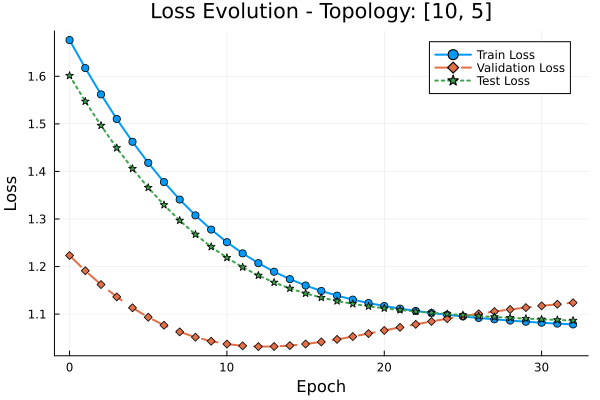

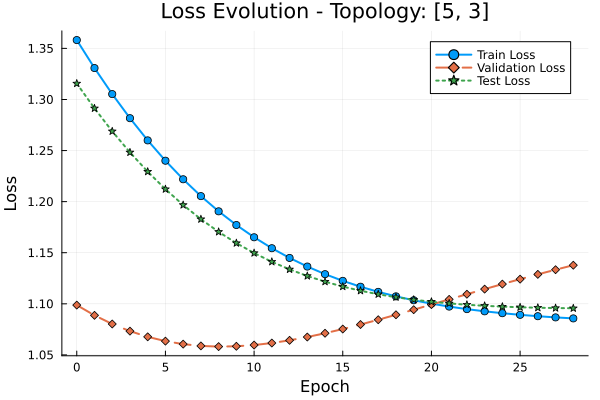

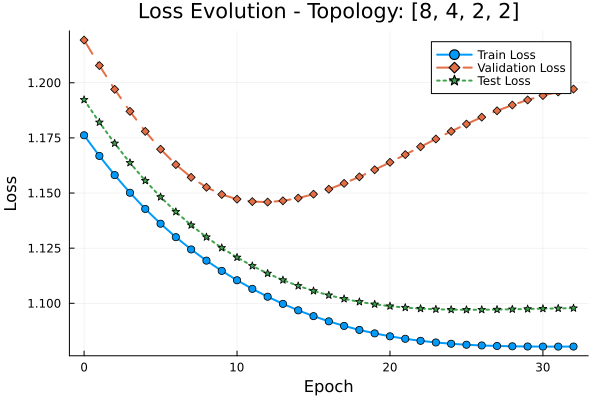

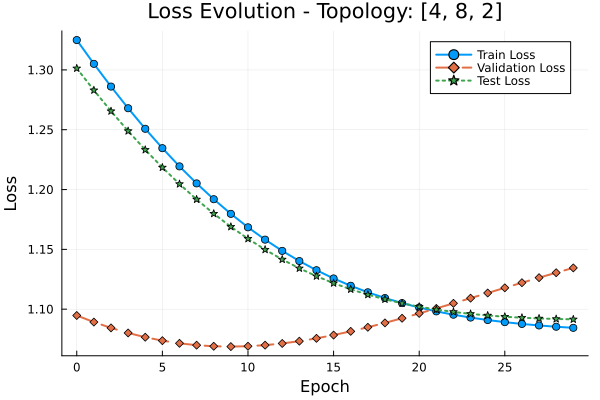

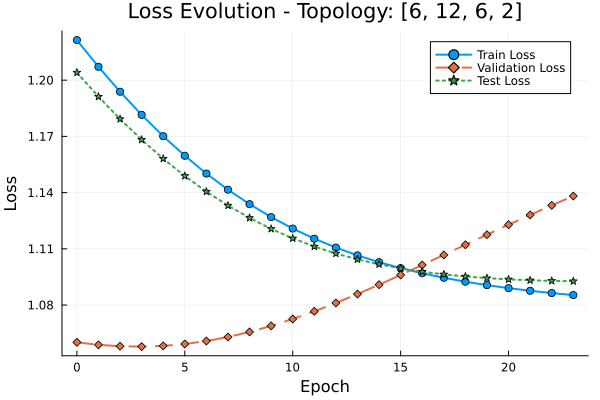

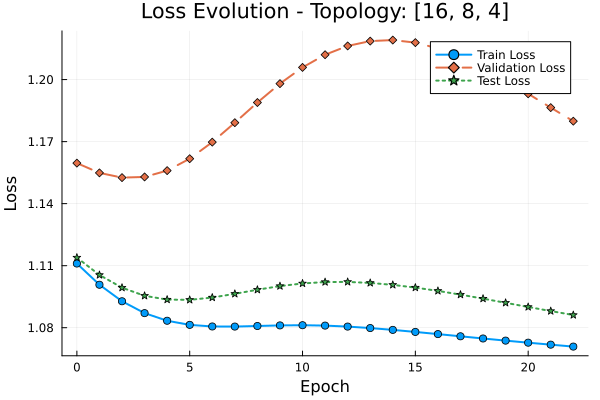

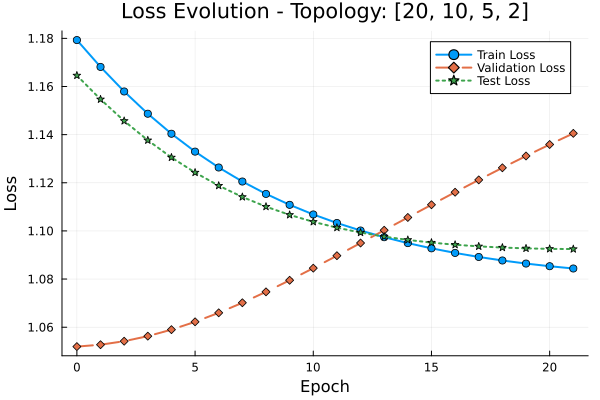

In [29]:
using Plots

# --- List of architectures to try ---
architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2] ,
    [16, 8, 4],
    [8, 4, 2, 2],
    [20, 10, 5, 2] , 
    [5,3]  
]

# --- Store all results ---
results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()


for topo in architectures
    println("\nTraining architecture: ", topo)
    finalAnn, trainLoss, valLoss, testLoss = trainClassANN_v3(
        topo,
        (train_inputs, train_targets),
        validationDataset = (val_inputs, val_targets),
        testDataset = (test_inputs, test_targets),
        maxEpochs = 100,
        learningRate = 0.01,
        showText = false
    )
    results[string(topo)] = (trainLoss, valLoss, testLoss)
end
# results = [(topology1, (trainLoss1, valLoss1, testLoss1)), 
#            (topology2, (trainLoss2, valLoss2, testLoss2)), ...]



# --- Plotting all losses one plot for each model---
for (topology, (trainLoss, valLoss, testLoss)) in results
    epochs = 0:length(trainLoss)-1  # include cycle 0

    p = plot(epochs, trainLoss, label="Train Loss", lw=2, marker=:circle)
    
    if !isempty(valLoss)
        plot!(p, epochs, valLoss, label="Validation Loss", lw=2, linestyle=:dash, marker=:diamond)
    end
    
    if !isempty(testLoss)
        plot!(p, epochs, testLoss, label="Test Loss", lw=2, linestyle=:dot, marker=:star)
    end

    xlabel!("Epoch")
    ylabel!("Loss")
    title!("Loss Evolution - Topology: $(topology)")
    plot!(legend=:topright)
    
    display(p)  # show the plot
end


### Question 3.2
> ❓ Has the test error always decreased or has there come a point where it has started to increase?

`Answer here`

### Question 3.3
> ❓ How do the 3 precision values evolve?

`Answer here`

### Question 3.4
> ❓ Which criteria usually stop the training? Why?

`Answer here`

### Question 3.5
> ❓ To which cycle does the ANN returned by the function correspond? 

`Answer here`

# Julia Notes

Julia has a library that allows you to display all kinds of plots in a very simple way.  To load it, simply put `using Plots`, the documentation can be found at http://docs.juliaplots.org/. As always the first should be to install, ifg it is not already installed:

In [30]:
using Pkg; Pkg.add("Plots")

   Resolving package versions...
  No Changes to `C:\Users\gianp\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\gianp\.julia\environments\v1.11\Manifest.toml`


Actually, `Plots.jl` is not a package for displaying plots, but an interface to a set of libraries for displaying plots.  Plots.jl provides a set of functions that allow, in a unified way, to display plots using one or another library, with the same calls.  That is, what Plots.jl does is to interpret the commands and generate the plots using another graphics library, which it refers to as a backend. Therefore, it is possible to change the graphics library (backend) without having to modify the code, since the calls to the corresponding functions are the same for all backends. 

So, first of all, after loading `Plots`, is to select the backend you want to work with.  Julia provides a large number of widely used ones, which you have to install in the usual way if you want to use them. If you don't indicate which one you want to use, Julia defaults to choosing one depending on which ones are installed. To see which backend is being used, you can simply type `backend()`.

In [31]:
using Plots
backend()

Plots.GRBackend()

Some of the most common backends are: Plotly, PyPlot, PlotlyJS and GR. In general, to use a backend, you simply make a call to a function named after the backend itself, but in lowercase. For the 4 given as examples at the beginning of this paragraph, it would be with calls to `plotly()`, `pyplot()`, `plotlyjs()` and `gr()` respectively. As said before, in case it is not installed you will have to install it in the usual way, writing `Pkg.add("Plotly")`, `Pkg.add("PyPlot")`, `Pkg.add("PlotlyJS")` or `Pkg.add("GR")` respectively.   More information about the different backends can be found at https://docs.juliaplots.org/latest/backends/.

In [32]:
# Install the pyplot and plotly if you do not have it

Once the desired backend is loaded, or with the default backend, you can start plotting. The easiest way is to use the plot function, which receives two parameters: the series to be put on the x-axis, and the series to be put on the y-axis, both as vectors, for example: 

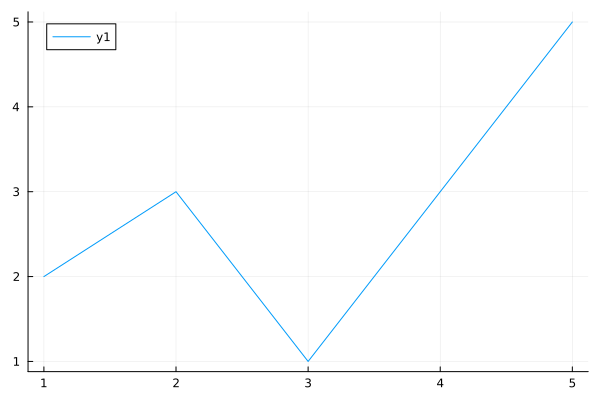

In [33]:
plot(1:5, [2, 3, 1, 3, 5])

In general, if you want to put more than one series on the graph, it is sufficient to specify one column per series in the matrix you pass to it for the y-axis data, for example:

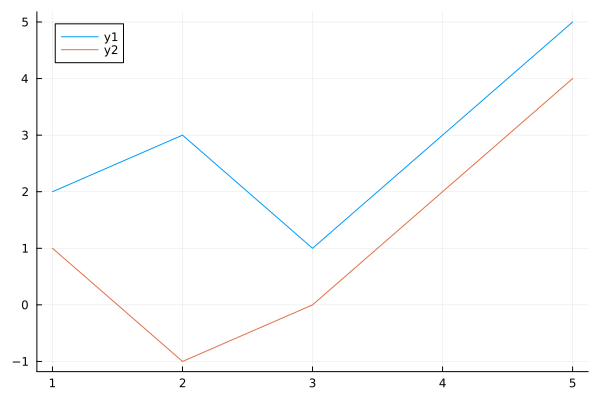

In [34]:
plot(1:5, [2 1; 3 -1; 1 0; 3 2; 5 4])

Another way to do this is to add more series to the plot object that has been created. That is, the call to plot returns an object that can be modified by further calls to `plot!` and passing it as the first parameter (remember that when the name of a function ends in `!` the argument passed is modified). The above example could be done in the following way: 

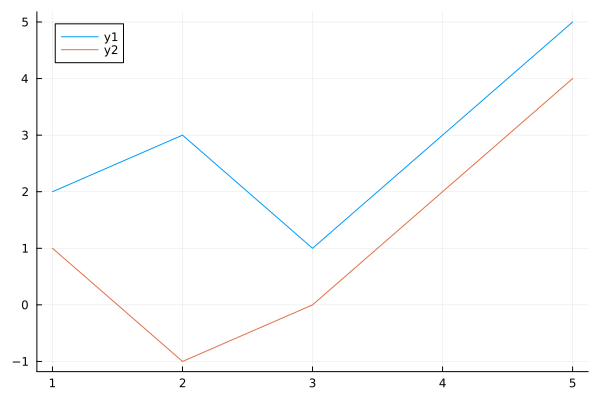

In [35]:
g = plot(1:5, [2, 3, 1, 3, 5]) 
plot!(g, 1:5, [1, -1, 0, 2, 4])

Or alternatively:

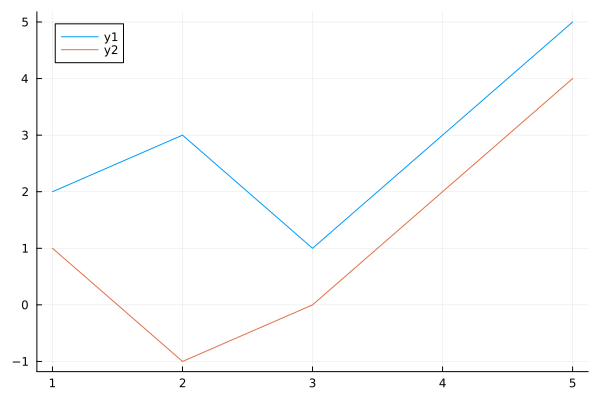

In [36]:
g = plot() 
plot!(g, 1:5, [2, 3, 1, 3, 5]) 
plot!(g, 1:5, [1, -1, 0, 2, 4])

For any of these three possibilities, if this is done in the command interpreter, the graph will appear.  In fact, in the second and third possibilities, more than one graph will appear as you create them. However, if this is done in a script, the graph does not automatically appear.  If we want it to appear, we have to make a call to display in this way: 

```julia
    display(g)
```

Besides the function plot, there are many other functions that allow you to represent other types of graphs and charts with the usual names, such as `heatmap`, `plot3d`, `scatter`, `histogram`, `boxplot`, `violin`, etc., all of them with their corresponding function ending in `!`.  As always, you can consult the help of a function by typing, for example: 

In [37]:
?boxplot

Base.Meta.ParseError: ParseError:
# Error @ e:\usc\master\courses\ML1\assignments\unit3\workspace\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y143sZmlsZQ==.jl:1:1
?boxplot
╙ ── not a unary operator

Generally speaking, it is desired to add more information to the graphs than just the data used in the graph.  This information usually includes title, labels on the axes, legend, markers at each point, line type, colours, etc.  This is usually done through attributes passed as keywords in function calls, such as `axis`, `label`, `line`, `fill`, `marker`, `ticks`, `title`, `xlabel`, `ylabel`, for example: 

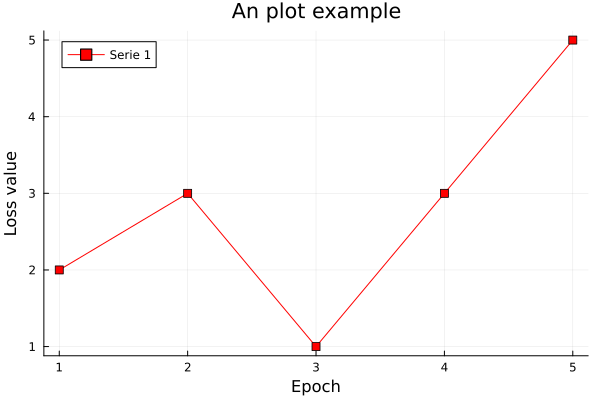

In [38]:
plot(1:5, [2, 3, 1, 3, 5], 
    xaxis = "Epoch", yaxis = "Loss value", title = "An plot example", 
    marker = :square, color = :red, label = "Serie 1")

A quick overview of the most common keywords can be found at https://docs.juliaplots.org/latest/attributes/.   On the other hand, https://docs.juliaplots.org/latest/generated/supported/tenéis has a complete list of the different types of series, keywords, markers, line styles and scales supported by each backend.  As you can see, the list of graphs and arguments is quite extensive, which gives you an idea of the enormous possibilities Julia offers when it comes to plotting graphs.

Another common issue when displaying graphs is to combine several graphs within a single window.  There are several methods to do this, the simplest and most commonly used being by using the keyword `layout` in the call to the corresponding function to generate the graph containing all of them.  In this sense, it is the easiest way to generate the graphs independently, and combine them later in a new call using the keyword `layout`, which receives as parameter a tuple with the number of rows and columns of the matrix of graphs, for example:

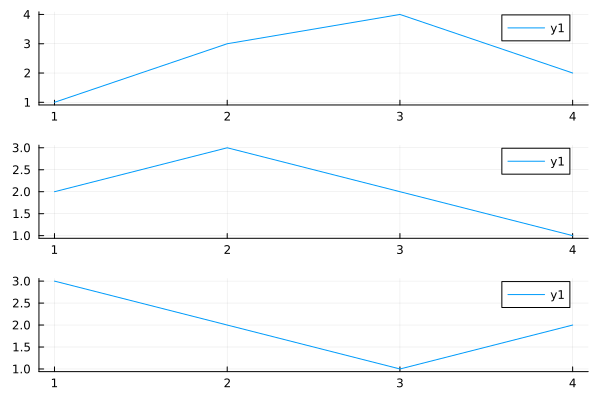

In [39]:
p1 = plot(1:4, [1, 3, 4, 2]); 
p2 = plot(1:4, [2, 3, 2, 1]); 
p3 = plot(1:4, [3, 2, 1, 2]); 
plot(p1, p2, p3, layout = (3,1))

As you could see, the plots asre arrange in a column layout each one in a row, alternatively, if we invert the order the result could be set in a single row as in:

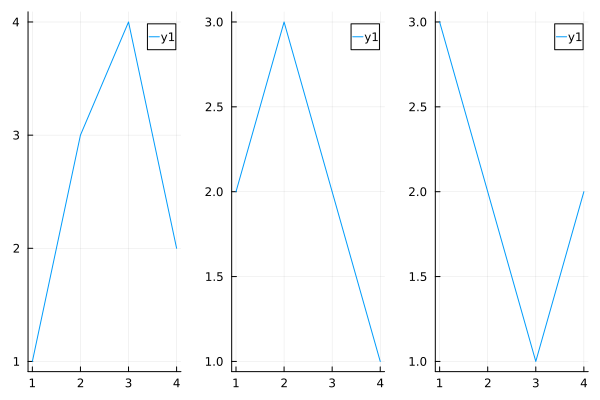

In [40]:
plot(p1, p2, p3, layout = (1,3))

More information on how to combine graphics can be found at https://docs.juliaplots.org/latest/layouts/. 

Finally, another very common action is to save the generated graphs.  This can be done by means of the savefig function, which receives as parameters the graph to save and the file name. From the extension indicated in the file name, Julia saves the graph in the indicated format. Some of the most typical formats are `pdf`, `png` or `ps`.  Although this is a very easy way to save the graphs, not all file types are supported by all backends. At https://docs.juliaplots.org/latest/output/ you can check the file formats supported by each backend. For exple with the previous example.

```julia
    g = plot(p1, p2, p3, layout = (1,3))
    savefig(g, 'ExampleSingleRow.png')
```